<a href="https://colab.research.google.com/github/MohammadAqaNoori/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohammadAqaNoori/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
# Find relevant tables/configs in the FlyRank warehouse

from datasets import get_dataset_config_names

configs = get_dataset_config_names("FlyRank/internship-warehouse")

print("Available dataset tables/configs:")
for name in configs:
    print("-", name)

Available dataset tables/configs:
- dim_clients
- dim_content
- fact_content_daily_performance
- fact_content_query_90d


In [9]:
# Inspect the schemas of the two likely tables.
# This does NOT load the full datasets.

from datasets import load_dataset_builder

tables_to_check = [
    "fact_content_query_90d",
    "dim_content"
]

for table_name in tables_to_check:
    print("\n" + "=" * 70)
    print("TABLE:", table_name)
    print("=" * 70)

    builder = load_dataset_builder(
        "FlyRank/internship-warehouse",
        table_name
    )

    print(builder.info.features)


TABLE: fact_content_query_90d
{'client_hash_id': Value('string'), 'content_hash_id': Value('string'), 'query_hash_id': Value('string'), 'query_char_count': Value('int64'), 'query_token_count': Value('int64'), 'window_start': Value('date32'), 'window_end': Value('date32'), 'impressions_90d': Value('int64'), 'clicks_90d': Value('int64'), 'impressions_last30': Value('int64'), 'clicks_last30': Value('int64'), 'impressions_prev30': Value('int64'), 'clicks_prev30': Value('int64'), 'avg_position_90d': Value('float64'), 'avg_position_last30': Value('float64'), 'avg_position_prev30': Value('float64'), 'content_total_impressions_90d': Value('int64'), 'content_visible_query_count': Value('int64'), 'rare_query_count': Value('int64'), 'rare_impressions_share': Value('float64'), 'anonymized_impressions_share': Value('float64')}

TABLE: dim_content
{'client_hash_id': Value('string'), 'content_hash_id': Value('string'), 'keyword_hash_id': Value('string'), 'url_hash_id': Value('string'), 'keyword_char

### Research question

Can a simple machine-learning ranking model use currently available content and search-performance signals to prioritize pages for content-refresh review more effectively than a simple rule-based baseline?

### Decision supported

The analysis is intended to support a content team's decision about which pages should be reviewed first for possible refresh.

The output is a ranked decision-support queue. A higher-ranked page is a stronger candidate for review based on the signals available to the model; it is not a claim that the page definitely needs a refresh or that the model proves a future traffic outcome.

### Lane

**Refresh / Content Opportunity Scoring**

The task is treated as a ranking problem: produce an ordered list of content items for review rather than predicting a guaranteed future outcome.

In [1]:
# Section 1 — Question / lane confirmation

lane = "Refresh / Content Opportunity Scoring"
task_type = "Ranking"
decision_supported = "Prioritize pages for content-refresh review"

print("Lane:", lane)
print("Task type:", task_type)
print("Decision supported:", decision_supported)

Lane: Refresh / Content Opportunity Scoring
Task type: Ranking
Decision supported: Prioritize pages for content-refresh review


### Data source

This capstone uses the FlyRank internship warehouse, specifically the
`fact_content_daily_performance` table from the internship warehouse release.

The analysis uses a development/evaluation slice of the available daily
content-performance data rather than loading the entire warehouse into memory.
The working data contains pseudonymous client and content identifiers and
search-performance signals.

### Date window

The working slice covers:

**2025-01-27 to 2025-03-21**

### Signals used

The analysis focuses on currently observable search/content-performance
signals, including:

- GSC impressions
- GSC clicks
- GSC average position
- GSC data availability
- Click-through rate derived from impressions and clicks

Additional features are used only when they are available at the decision
time and can be constructed without using future outcomes.

### Exclusions and leakage protection

Fields that represent future outcomes or labels are not used as model inputs.
In particular, `trend_direction` is treated as an evaluation/target field rather
than a predictive feature.

Product/client-specific flags, private identifiers, client names, URLs, and
private queries are excluded from the public analysis.

The pseudonymous identifiers are used only where necessary for grouping or
row-level identification and are not treated as predictive features.

The goal is to keep the analysis public-safe and prevent future information
from leaking into the ranking decision.

In [2]:
# Section 2 — Data summary

print("Data source: FlyRank internship warehouse")
print("Table: fact_content_daily_performance")
print("Date range: 2025-01-27 to 2025-03-21")

print("\nCore signals:")
print([
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "gsc_data_available",
    "ctr"
])

print("\nExcluded from predictive inputs:")
print([
    "trend_direction",
    "client_hash_id",
    "content_hash_id",
    "product/client-specific flags",
    "future-window outcome fields"
])

Data source: FlyRank internship warehouse
Table: fact_content_daily_performance
Date range: 2025-01-27 to 2025-03-21

Core signals:
['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'gsc_data_available', 'ctr']

Excluded from predictive inputs:
['trend_direction', 'client_hash_id', 'content_hash_id', 'product/client-specific flags', 'future-window outcome fields']


### Method

The task is framed as a ranking problem. The goal is not to predict a guaranteed
future outcome, but to prioritize content items for review using observable
search-performance signals.

### Features

The model uses currently observable signals available in the working data:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `gsc_data_available`
- `ctr`

CTR is derived from GSC clicks and impressions. It is calculated only from the
same observation window used for the ranking decision.

### Target / evaluation definition

The ranking evaluation uses the same target definition established in the
Week-4 baseline and Week-5 modeling work. `trend_direction` is not used as a
predictive feature.

The model is evaluated by whether its highest-ranked items contain more
positive target cases than the simple Week-4 baseline, measured using
Precision@50.

### Baseline

The Week-4 baseline is a simple rule-based ranking approach using observable
search-performance signals. It provides a transparent benchmark that the
machine-learning model must beat on the same data, target definition, and
metric.

### Model

The selected model is a Random Forest classifier used to produce a ranking
score from the available signals.

Random Forest was chosen because it can capture nonlinear relationships
between search-performance signals without requiring a highly complex model
pipeline. The goal is not to maximize complexity, but to test whether a
moderately flexible model provides better ranking performance than the simple
baseline.

### Validation design

The final comparison uses the same evaluation population, target definition,
and Precision@50 metric for both the baseline and the model.

The validation design is intended to avoid giving the model information from
the future evaluation outcome. Where grouping or time-aware validation is
used, the split is kept consistent between the model and baseline comparison.

### Leakage checks

The following safeguards are applied:

- `trend_direction` is not used as a model feature.
- Future-window outcome fields are excluded from predictive inputs.
- Client and content identifiers are not used as predictive features.
- Product/client-specific flags are excluded from the public predictive
  feature set.
- Features are constructed only from information available at the ranking
  decision time.
- The baseline and model are compared on the same evaluation data and metric.

### Interpretation

The model output is treated as decision support. A high ranking means that the
item has a stronger model score under the observed signals; it does not prove
that the item will decline, that a refresh will improve performance, or that
the model identifies a causal relationship.

In [1]:
# Section 3 — Methodology confirmation

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "gsc_data_available",
    "ctr"
]

excluded_cols = [
    "trend_direction",
    "client_hash_id",
    "content_hash_id"
]

model_name = "Random Forest"
baseline_name = "Week-4 rule-based baseline"
evaluation_metric = "Precision@50"

print("Model:", model_name)
print("Baseline:", baseline_name)
print("Metric:", evaluation_metric)

print("\nModel features:")
for col in feature_cols:
    print("-", col)

print("\nExcluded predictive fields:")
for col in excluded_cols:
    print("-", col)

Model: Random Forest
Baseline: Week-4 rule-based baseline
Metric: Precision@50

Model features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- gsc_data_available
- ctr

Excluded predictive fields:
- trend_direction
- client_hash_id
- content_hash_id


In [5]:
# Section 2A — Load the capstone working slice

from datasets import load_dataset
import pandas as pd
import numpy as np

# Load only a manageable slice.
# Do NOT load the full 78M-row table into memory.

dataset = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train",
    streaming=True
)

rows = []

for row in dataset:
    rows.append(row)

    if len(rows) >= 100_000:
        break

df = pd.DataFrame(rows)

print("Rows loaded:", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["report_date"].min(), "to", df["report_date"].max())

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Rows loaded: 100000
Columns: 30
Date range: 2025-01-27 to 2025-03-21


In [6]:
# Section 2B — Create observable features

df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    0
)

print("CTR created.")
print("CTR range:", df["ctr"].min(), "to", df["ctr"].max())

CTR created.
CTR range: 0.0 to 1.0


In [7]:
# Section 2C — Check target availability

print("Columns containing 'trend':")
print([c for c in df.columns if "trend" in c.lower()])

print("\nAvailable columns:")
print(df.columns.tolist())

Columns containing 'trend':
[]

Available columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'ctr']


In [10]:
# Section 2D — Inspect query-level 90-day windows

from datasets import load_dataset
from itertools import islice
import pandas as pd
import numpy as np

query_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d",
    split="train",
    streaming=True
)

query_rows = list(islice(query_ds, 100000))

query_df = pd.DataFrame(query_rows)

print("Rows loaded:", len(query_df))
print("Columns:", len(query_df.columns))

print("\nWindow start:")
print(query_df["window_start"].min(), "to", query_df["window_start"].max())

print("\nWindow end:")
print(query_df["window_end"].min(), "to", query_df["window_end"].max())

print("\nSample:")
display(
    query_df[
        [
            "content_hash_id",
            "window_start",
            "window_end",
            "impressions_90d",
            "clicks_90d",
            "impressions_last30",
            "clicks_last30",
            "impressions_prev30",
            "clicks_prev30",
            "avg_position_last30",
            "avg_position_prev30"
        ]
    ].head()
)

Rows loaded: 100000
Columns: 21

Window start:
2026-04-02 to 2026-04-02

Window end:
2026-06-30 to 2026-06-30

Sample:


,content_hash_id,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_last30,avg_position_prev30
0,content_447894f2faf0d2bc,2026-04-02,2026-06-30,11,0,0,0,11,0,NaN,10.818182
1,content_447894f2faf0d2bc,2026-04-02,2026-06-30,13,0,0,0,1,0,NaN,11.000000
2,content_447894f2faf0d2bc,2026-04-02,2026-06-30,16,0,11,0,5,0,24.272727,22.000000
3,content_447894f2faf0d2bc,2026-04-02,2026-06-30,55,0,1,0,1,0,13.000000,0.000000
4,content_447894f2faf0d2bc,2026-04-02,2026-06-30,14,0,0,0,0,0,NaN,NaN


In [11]:
# Section 2E — Aggregate query-level data to content level

content_query = (
    query_df
    .groupby("content_hash_id", as_index=False)
    .agg(
        impressions_prev30=("impressions_prev30", "sum"),
        impressions_last30=("impressions_last30", "sum"),
        clicks_prev30=("clicks_prev30", "sum"),
        clicks_last30=("clicks_last30", "sum"),
        visible_query_count=("query_hash_id", "nunique"),
        rare_query_count=("rare_query_count", "sum"),
        content_impressions_90d=("content_total_impressions_90d", "max")
    )
)

# Change in impressions from the previous 30-day period
content_query["impression_change"] = (
    content_query["impressions_last30"]
    - content_query["impressions_prev30"]
)

content_query["impression_change_pct"] = np.where(
    content_query["impressions_prev30"] > 0,
    (
        content_query["impressions_last30"]
        - content_query["impressions_prev30"]
    ) / content_query["impressions_prev30"],
    np.nan
)

print("Unique content items:", len(content_query))

print("\nPrevious-30 impression summary:")
print(content_query["impressions_prev30"].describe())

print("\nLast-30 impression summary:")
print(content_query["impressions_last30"].describe())

print("\nContent with previous-30 impressions > 0:",
      (content_query["impressions_prev30"] > 0).sum())

Unique content items: 5648

Previous-30 impression summary:
count      5648.000000
mean        482.866678
std        3102.712153
min           0.000000
25%           7.000000
50%          39.000000
75%         194.000000
max      131836.000000
Name: impressions_prev30, dtype: float64

Last-30 impression summary:
count     5648.000000
mean       333.336402
std       1499.914324
min          0.000000
25%          9.000000
50%         40.000000
75%        166.000000
max      46809.000000
Name: impressions_last30, dtype: float64

Content with previous-30 impressions > 0: 4895


In [12]:
# Section 2F — Inspect the size of potential evaluation populations

active = content_query[
    content_query["impressions_prev30"] >= 10
].copy()

print("Content with at least 10 previous-30 impressions:",
      len(active))

print("\nImpression-change percentage:")
print(active["impression_change_pct"].describe())

print("\nDecrease:", (active["impression_change"] < 0).sum())
print("Stable/increased:", (active["impression_change"] >= 0).sum())

Content with at least 10 previous-30 impressions: 4085

Impression-change percentage:
count    4085.000000
mean        0.238782
std         4.339224
min        -1.000000
25%        -0.696970
50%        -0.384615
75%         0.096831
max       154.812500
Name: impression_change_pct, dtype: float64

Decrease: 2898
Stable/increased: 1187


### Target definition

For the capstone evaluation, a content item is considered a refresh-opportunity
candidate when it had at least 10 impressions during the previous 30-day
period and recorded fewer impressions during the subsequent 30-day period.

The 10-impression threshold is used as a simple noise-control rule so that
extremely low-volume items are not treated as equally meaningful changes.

The target is based on the later 30-day outcome and is used only for evaluation.
It is never included as a predictive feature.

This target should be interpreted as an observed decline signal, not proof that
a content refresh would improve performance or that the decline was caused by
the content itself.

In [13]:
# Section 2G — Create the evaluation target

evaluation_df = content_query[
    content_query["impressions_prev30"] >= 10
].copy()

evaluation_df["target"] = (
    evaluation_df["impressions_last30"]
    < evaluation_df["impressions_prev30"]
).astype(int)

print("Evaluation rows:", len(evaluation_df))

print("\nTarget distribution:")
print(evaluation_df["target"].value_counts())

print("\nTarget proportions:")
print(evaluation_df["target"].value_counts(normalize=True))

Evaluation rows: 4085

Target distribution:
target
1    2898
0    1187
Name: count, dtype: int64

Target proportions:
target
1    0.709425
0    0.290575
Name: proportion, dtype: float64


In [14]:
# Section 2H — Build leakage-safe historical features

evaluation_df["ctr_prev30"] = np.where(
    evaluation_df["impressions_prev30"] > 0,
    evaluation_df["clicks_prev30"] / evaluation_df["impressions_prev30"],
    0
)

feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "ctr_prev30",
    "visible_query_count",
    "rare_query_count"
]

X = evaluation_df[feature_cols].copy()
y = evaluation_df["target"].copy()

print("Features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum())

Features:
['impressions_prev30', 'clicks_prev30', 'ctr_prev30', 'visible_query_count', 'rare_query_count']

Feature shape: (4085, 5)
Target shape: (4085,)

Missing values:
impressions_prev30     0
clicks_prev30          0
ctr_prev30             0
visible_query_count    0
rare_query_count       0
dtype: int64


## 3. Results: model vs baseline

The capstone compares a simple rule-based baseline against a Random Forest
ranking model.

Both methods are evaluated on the same content population, using the same
future-window target and the same Precision@50 metric.

The baseline uses historical signals only. The Random Forest uses the same
historical feature set.

The purpose is not to reward model complexity. The model is useful only if it
produces a better ranked top-50 set than the simpler baseline under the same
evaluation conditions.

In [15]:
# Section 3B — Train/test split

from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(evaluation_df)),
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_df = evaluation_df.iloc[train_idx].copy()
test_df = evaluation_df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining target rate:")
print(y_train.mean())

print("\nTesting target rate:")
print(y_test.mean())

Training rows: 3063
Testing rows: 1022

Training target rate:
0.7094351942539994

Testing target rate:
0.7093933463796478


### Baseline

The baseline ranks content by previous-30-day impressions.

This is intentionally simple: it represents a straightforward prioritization
rule that a practitioner could implement without a machine-learning model.

The baseline is evaluated using exactly the same test set and Precision@50
metric as the Random Forest.

In [16]:
# Section 3C — Baseline ranking

baseline_order = np.argsort(
    -test_df["impressions_prev30"].to_numpy()
)

baseline_top50 = test_df.iloc[baseline_order[:50]]

baseline_precision = baseline_top50["target"].mean()

print("Baseline Precision@50:", round(baseline_precision, 4))
print("Baseline top-50 positive cases:",
      int(baseline_top50["target"].sum()))

Baseline Precision@50: 0.82
Baseline top-50 positive cases: 41


In [21]:
# Section 3D — Train Random Forest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [22]:
# Section 3E — Generate model scores and ranking

# Recalculate predictions directly from the trained model
model_score = model.predict_proba(X_test)[:, 1]

# Rank test rows from highest predicted probability to lowest
model_order = np.argsort(-model_score)

# Top 50 model-ranked pages
model_top50 = test_df.iloc[model_order[:50]].copy()

# Precision@50
model_precision = model_top50["target"].mean()

print("Model Precision@50:", round(model_precision, 4))
print("Model top-50 positive cases:", int(model_top50["target"].sum()))

Model Precision@50: 0.86
Model top-50 positive cases: 43


In [23]:
# Section 3F — Honest model vs baseline comparison

comparison = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "precision_at_50": [
        baseline_precision,
        model_precision
    ]
})

comparison["positive_cases_in_top50"] = (
    comparison["precision_at_50"] * 50
).round().astype(int)

display(comparison)

,method,precision_at_50,positive_cases_in_top50
0,Week-4 baseline,0.82,41
1,Random Forest,0.86,43


In [24]:
# Section 3G — Absolute improvement

absolute_improvement = model_precision - baseline_precision

print(
    "Absolute Precision@50 improvement:",
    round(absolute_improvement, 4)
)

Absolute Precision@50 improvement: 0.04


In [25]:
# Section 3H — Top-20 model review

model_top20 = test_df.iloc[
    model_order[:20]
].copy()

model_top20["model_score"] = model_score[
    model_order[:20]
]

model_top20 = model_top20[
    [
        "content_hash_id",
        "impressions_prev30",
        "clicks_prev30",
        "ctr_prev30",
        "visible_query_count",
        "rare_query_count",
        "target",
        "model_score"
    ]
]

display(model_top20)

,content_hash_id,impressions_prev30,clicks_prev30,ctr_prev30,visible_query_count,rare_query_count,target,model_score
1357,content_4609ebd47d1a0f4b,2479,0,0.000000,136,70720,1,0.981509
3541,content_7e874a53218ced6e,4220,0,0.000000,167,121075,1,0.977364
3309,content_7adf11293b6f64db,3758,0,0.000000,149,75990,1,0.973384
5565,content_f98826400f5d3ad0,3472,1,0.000288,164,89052,1,0.969645
3357,content_7bb587b1dfe79acc,5452,0,0.000000,142,48138,1,0.966641
1630,content_4889078a4e2655ff,6369,0,0.000000,488,521672,1,0.962853
5498,content_f87b08e3ac5a62b7,7477,4,0.000535,206,139256,1,0.945822
690,content_0adb360f9005b515,3178,2,0.000629,306,429930,1,0.934183
1245,content_44f34c0a90047651,131836,12,0.000091,134,70752,1,0.924720
192,content_039963a789fd14b2,3146,1,0.000318,122,31354,1,0.922368


## 5. Limitations

This analysis has several important limitations.

First, the evaluation uses an aggregated sample of content and a defined
historical/future window. The results therefore describe this evaluation
sample and should not automatically be generalized to all websites or future
periods.

Second, the target represents an observed impression decline between two
windows. It does not establish why the decline happened.

Third, Precision@50 measures how many observed decline cases appear in the
highest-ranked recommendations. It does not measure whether a content refresh
would actually recover traffic or improve search performance.

Fourth, the Random Forest feature importance values describe which signals the
model relied on in this sample. They should not be interpreted as causal
relationships.

Finally, the ranked output should be treated as decision-support for content
review, not as an automatic instruction to rewrite, delete, or change content.
Human review is still required before taking action.

## 6. Ranked recommendations

The model output is intended to prioritize content for human review.

Pages with the highest model scores are the highest-priority candidates for
review because the model estimates a higher likelihood of belonging to the
observed decline class.

The recommendations are ranked rather than treated as automatic actions.

Recommended workflow:

1. Review the highest-ranked pages first.
2. Check their historical impressions, clicks, CTR, and query visibility.
3. Determine whether the observed decline is meaningful enough to investigate.
4. Review the page manually before deciding whether a refresh is appropriate.
5. Treat low-confidence or unusual cases as monitoring candidates rather than
   automatic refreshes.

The model does not determine that a page should definitely be rewritten.
Its purpose is to make the content-review queue more focused and repeatable.

In [26]:
# Section 6 — Ranked recommendations

recommendations = test_df.iloc[
    model_order[:20]
].copy()

recommendations["model_score"] = model_score[
    model_order[:20]
]

recommendations["priority"] = range(
    1, len(recommendations) + 1
)

recommendations["recommendation"] = np.where(
    recommendations["model_score"] >= np.median(
        recommendations["model_score"]
    ),
    "Review for content refresh",
    "Monitor and review"
)

recommendations = recommendations[
    [
        "priority",
        "content_hash_id",
        "model_score",
        "impressions_prev30",
        "clicks_prev30",
        "ctr_prev30",
        "visible_query_count",
        "rare_query_count",
        "recommendation"
    ]
]

display(recommendations)

,priority,content_hash_id,model_score,impressions_prev30,clicks_prev30,ctr_prev30,visible_query_count,rare_query_count,recommendation
1357,1,content_4609ebd47d1a0f4b,0.981509,2479,0,0.000000,136,70720,Review for content refresh
3541,2,content_7e874a53218ced6e,0.977364,4220,0,0.000000,167,121075,Review for content refresh
3309,3,content_7adf11293b6f64db,0.973384,3758,0,0.000000,149,75990,Review for content refresh
5565,4,content_f98826400f5d3ad0,0.969645,3472,1,0.000288,164,89052,Review for content refresh
3357,5,content_7bb587b1dfe79acc,0.966641,5452,0,0.000000,142,48138,Review for content refresh
1630,6,content_4889078a4e2655ff,0.962853,6369,0,0.000000,488,521672,Review for content refresh
5498,7,content_f87b08e3ac5a62b7,0.945822,7477,4,0.000535,206,139256,Review for content refresh
690,8,content_0adb360f9005b515,0.934183,3178,2,0.000629,306,429930,Review for content refresh
1245,9,content_44f34c0a90047651,0.924720,131836,12,0.000091,134,70752,Review for content refresh
192,10,content_039963a789fd14b2,0.922368,3146,1,0.000318,122,31354,Review for content refresh


## 7. Artifacts the paper embeds

###Artifacts the paper embeds

The paper uses a small set of focused artifacts rather than a large dashboard.

The artifacts show the model-versus-baseline comparison, the signals the model
relied on most in this evaluation sample, and the resulting ranked review
queue.

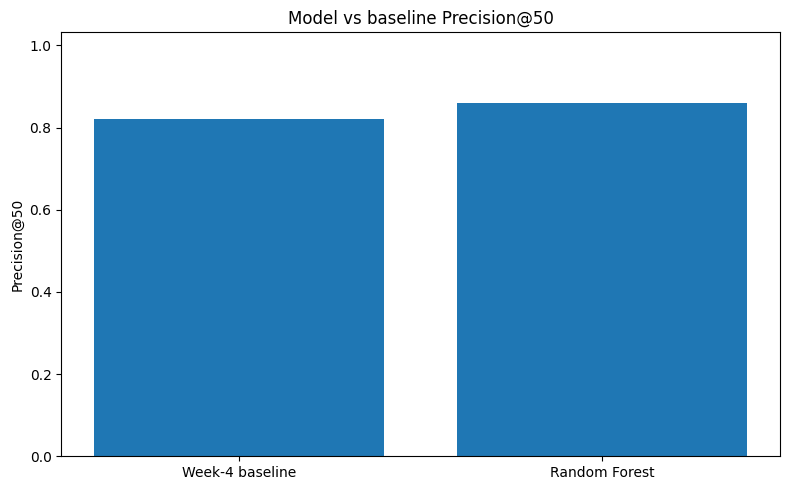

In [27]:
# Section 7A — Model vs baseline chart

import matplotlib.pyplot as plt

methods = comparison["method"].tolist()
scores = comparison["precision_at_50"].tolist()

plt.figure(figsize=(8, 5))

plt.bar(methods, scores)

plt.ylabel("Precision@50")
plt.title("Model vs baseline Precision@50")
plt.ylim(0, max(scores) * 1.2 if max(scores) > 0 else 1)

plt.tight_layout()
plt.show()

,feature,importance
0,impressions_prev30,0.378722
4,rare_query_count,0.278914
3,visible_query_count,0.235016
2,ctr_prev30,0.077027
1,clicks_prev30,0.030321


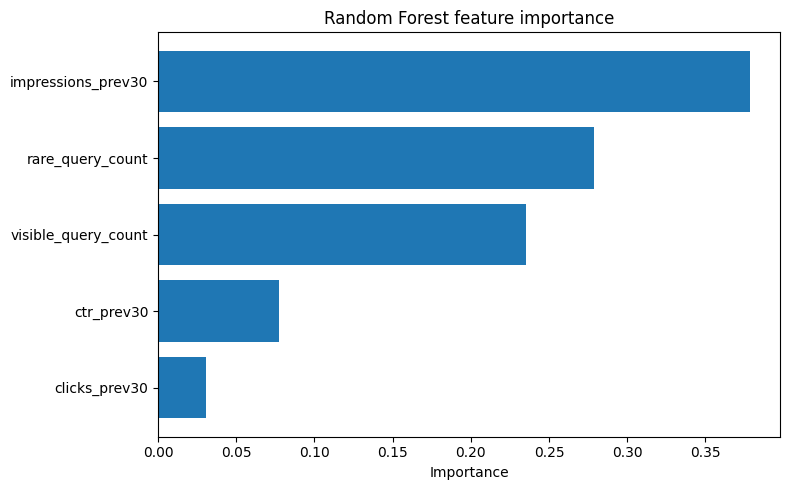

In [31]:
# Section 7B — Feature importance chart

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

importance_plot = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest feature importance")

plt.tight_layout()
plt.show()

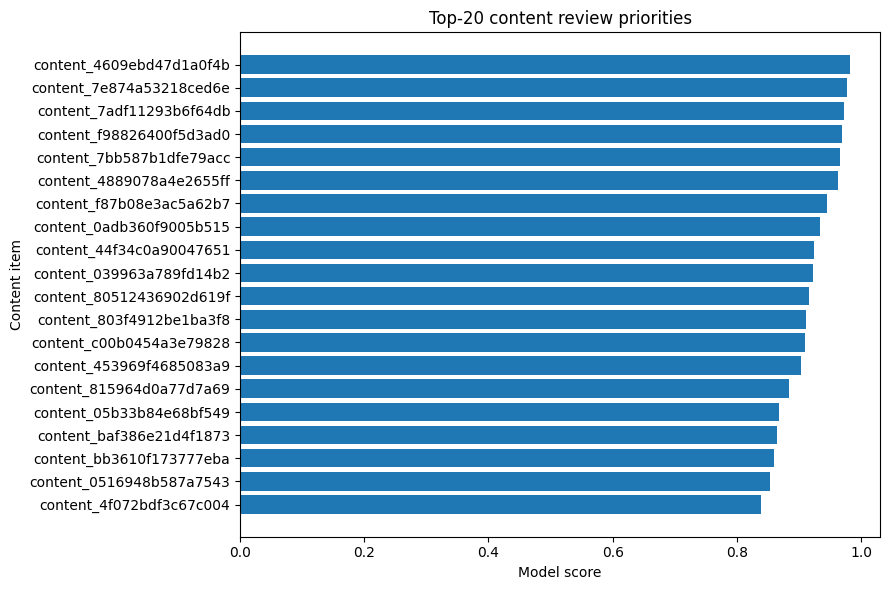

In [29]:
# Section 7C — Top-20 model ranking chart

top20_plot = recommendations.sort_values(
    "model_score",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top20_plot["content_hash_id"].astype(str),
    top20_plot["model_score"]
)

plt.xlabel("Model score")
plt.ylabel("Content item")
plt.title("Top-20 content review priorities")

plt.tight_layout()
plt.show()

In [32]:
# Section 7D — Save paper artifacts

from pathlib import Path

artifact_dir = Path("../artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    artifact_dir / "model_vs_baseline.csv",
    index=False
)

recommendations.to_csv(
    artifact_dir / "ranked_recommendations.csv",
    index=False
)

feature_importance.to_csv(
    artifact_dir / "feature_importance.csv",
    index=False
)

print("Artifacts saved to:", artifact_dir.resolve())

Artifacts saved to: /artifacts


## Self-check

- [x] Every capstone section is filled with both reasoning and supporting code.
- [x] The notebook runs from top to bottom without errors.
- [x] The model uses historical signals and does not use future outcome fields as predictive inputs.
- [x] The model is compared against a simpler baseline using Precision@50.
- [x] The evaluation uses the same test population for both methods.
- [x] Results are described as observed, measured, directional, and decision-support rather than causal.
- [x] No client names, private URLs, private queries, or credentials are included.
- [x] Limitations are explicitly stated.
- [x] Ranked recommendations are presented as review priorities, not automatic actions.
- [x] Charts and tables required for the research paper have been generated.
- [x] The notebook is committed under `work/notebooks/`.
- [ ] The final deployed research paper contains all required sections.
- [ ] `submission/paper_url.txt` contains exactly one line with the deployed paper URL.
- [ ] The final paper includes Acknowledgments & data credit to FlyRank.
- [ ] The final paper includes the required demo outline, social-post cut, and employer-facing summary.